<a href="https://colab.research.google.com/github/5ahar-K/Project/blob/main/RMSE%2C%20defocused%2C%20stationary%20in%20time.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LINK PARAMETER SUMMARY
  wz                = 3.0908 cm
  Regime            = Gaussian (wz<ra)
  eta               = 99.466677 %  (-0.02 dB)
  delta (defocus)   = 3.0000 mm
  fc                = 50.00 mm
  fc_eff = fc+delta = 53.0000 mm  (used in simulation)
  delta/fc          = 6.00 %
  sigma_I           = 3.0000 mm 
  sigma_I/wa        = 3.0000 

Building Malaga CDF... done.

  L= 10  Pt= -25.0 dBm  RMSE=505.991 um  P_int=0.6166 (geom=0.0000, snr=0.6166)
  L= 10  Pt= -22.6 dBm  RMSE=488.219 um  P_int=0.4209 (geom=0.0000, snr=0.4209)
  L= 10  Pt= -20.3 dBm  RMSE=467.154 um  P_int=0.2584 (geom=0.0000, snr=0.2584)
  L= 10  Pt= -17.9 dBm  RMSE=441.392 um  P_int=0.1468 (geom=0.0000, snr=0.1468)
  L= 10  Pt= -15.5 dBm  RMSE=411.807 um  P_int=0.0773 (geom=0.0000, snr=0.0773)
  L= 10  Pt= -13.2 dBm  RMSE=383.662 um  P_int=0.0410 (geom=0.0000, snr=0.0410)
  L= 10  Pt= -10.8 dBm  RMSE=362.210 um  P_int=0.0209 (geom=0.0000, snr=0.0209)
  L= 10  Pt=  -8.4 dBm  RMSE=344.975 um  P_int=0.0108 (geom

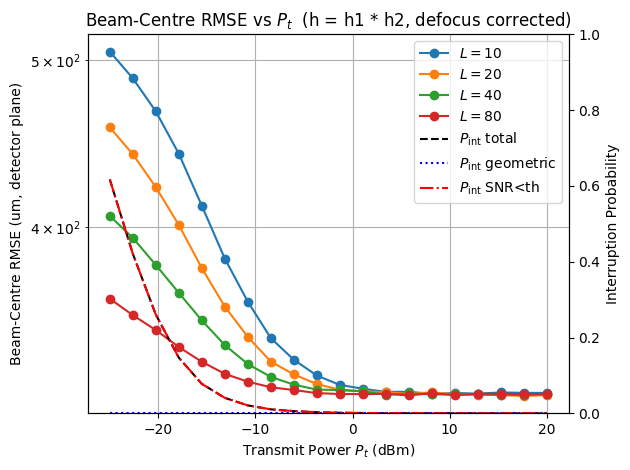

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc, kv, gamma
from scipy.integrate import cumulative_trapezoid
import math

def Q(x):
    return 0.5 * erfc(x / np.sqrt(2.0))

def compute_link_params(lam, Z, Cn2, w0, fc, ra, wa):
    kf    = 2 * np.pi / lam
    rho_Z = (0.55 * Cn2 * kf**2 * Z)**(-3/5)
    Theta = 1 + 2 * w0**2 / rho_Z**2
    wz    = w0 * np.sqrt(1 + Theta * (lam * Z / (np.pi * w0**2))**2)
    eta   = 1 - np.exp(-2 * ra**2 / wz**2)
    sigma_I = 3* wa
    delta   = sigma_I * fc / ra
    fc_eff  = fc + delta
    print("=" * 55)
    print("LINK PARAMETER SUMMARY")
    print("=" * 55)
    print(f"  wz                = {wz*100:.4f} cm")
    print(f"  Regime            = {'Gaussian (wz<ra)' if wz < ra else 'Airy (wz>ra)'}")
    print(f"  eta               = {eta*100:.6f} %  ({10*np.log10(max(eta,1e-30)):.2f} dB)")
    print(f"  delta (defocus)   = {delta*1e3:.4f} mm")
    print(f"  fc                = {fc*1e3:.2f} mm")
    print(f"  fc_eff = fc+delta = {fc_eff*1e3:.4f} mm  (used in simulation)")
    print(f"  delta/fc          = {delta/fc*100:.2f} %")
    print(f"  sigma_I           = {sigma_I*1e3:.4f} mm ")
    print(f"  sigma_I/wa        = {sigma_I/wa:.4f} ")
    print("=" * 55)
    print()
    return {"wz": wz, "eta": eta, "sigma_I": sigma_I, "delta": delta, "fc_eff": fc_eff}

def malaga_pdf(h, alpha, beta, g, Omega):
    h = np.asarray(h, dtype=float)
    h = np.maximum(h, 1e-300)
    AM = (2 * alpha**(alpha/2.0) / (g**(1 + alpha/2.0) * gamma(alpha))) * \
         ((g * beta / (g * beta + Omega))**(beta + alpha/2.0))
    beta_int = int(beta)
    if beta_int != beta:
        raise ValueError("beta must be an integer.")
    out = np.zeros_like(h)
    for m in range(1, beta_int + 1):
        am = (math.comb(beta_int - 1, m - 1) *
              (g * beta + Omega)**(1 - m/2.0) / math.factorial(m - 1) *
              (Omega / g)**(m - 1) *
              (alpha / beta)**(m/2.0))
        nu  = alpha - m
        arg = 2.0 * np.sqrt(alpha * beta * h / (g * beta + Omega))
        out += am * (h**((alpha + m)/2.0 - 1.0)) * kv(nu, arg)
    return AM * out

def build_malaga_cdf(alpha, beta, g, Omega, h_max=50.0, grid_n=200_000):
    h_grid    = np.linspace(0.0, h_max, grid_n)
    h_grid[0] = 1e-12
    pdf       = malaga_pdf(h_grid, alpha, beta, g, Omega)
    cdf       = cumulative_trapezoid(pdf, h_grid, initial=0.0)
    cdf      /= cdf[-1]
    return h_grid, cdf

def sample_malaga_batch(h_grid, cdf, size, rng):
    return np.interp(rng.random(size), cdf, h_grid)

def sample_h1_batch(Z, zeta1, h_grid, cdf, size, rng):
    return np.exp(-zeta1 * Z) * sample_malaga_batch(h_grid, cdf, size, rng)

def compute_h2_batch(theta_x, theta_y, Na, wa, wf, fc_eff, sigma_I):
    """
    Spot centre x0 = fc_eff * theta  (exact defocused ray trace, fc_eff = fc + delta).
    """
    w_prime  = wa + wf
    x0       = fc_eff * theta_x
    y0       = fc_eff * theta_y
    i        = np.arange(Na)
    j        = np.arange(Na)
    x_left   = (i - 1 - Na/2) * w_prime + wf/2
    x_right  = (i     - Na/2) * w_prime - wf/2
    ax1      = (x_left[None, :]  - x0[:, None]) / sigma_I
    ax2      = (x_right[None, :] - x0[:, None]) / sigma_I
    px       = Q(ax1) - Q(ax2)
    y_bottom = (j - 1 - Na/2) * w_prime + wf/2
    y_top    = (j     - Na/2) * w_prime - wf/2
    ay1      = (y_bottom[None, :] - y0[:, None]) / sigma_I
    ay2      = (y_top[None, :]    - y0[:, None]) / sigma_I
    py       = Q(ay1) - Q(ay2)
    h2       = px[:, :, None] * py[:, None, :]
    s        = np.sum(h2, axis=(1, 2), keepdims=True)
    positive = (s > 0).squeeze()
    if np.any(positive):
        h2[positive] /= s[positive]
    return h2

def interruption_mask(theta_x, theta_y, Na, wa, wf, fc_eff):
    """Beam centre outside array — uses fc_eff for accurate position."""
    w_prime = wa + wf
    r_array = (Na * w_prime) / 2.0
    r_d     = np.sqrt((fc_eff * theta_x)**2 + (fc_eff * theta_y)**2)
    return r_d > r_array

def snr_mask(h1, Pt, mu, sigma_s, sigma0, eta, gamma_th_dB=5.0):
    """SNR below threshold — total power = eta * Pt * h1 (h2 sums to 1)."""
    gamma_th = 10 ** (gamma_th_dB / 10.0)
    P_rx     = eta * Pt * h1
    gamma    = (mu * P_rx)**2 / (sigma_s**2 * P_rx + sigma0**2)
    return gamma < gamma_th

def generate_R_batch(Pt, h1, h2, L, mu, sigma_s, sigma0, rng, eta=1.0, p1=0.5):
    B, Na, _ = h2.shape
    s      = (rng.random((B, L)) < p1).astype(float)
    h_full = h1[:, None, None] * h2
    s4     = s[:, None, None, :]
    h4     = h_full[:, :, :, None]
    Pt_rx  = eta * Pt
    mean   = mu * Pt_rx * h4 * s4
    var    = (sigma_s**2) * (Pt_rx * h4 * s4) + sigma0**2
    R      = rng.normal(mean, np.sqrt(var))
    return s, R

def joint_track_h_hat_batch(R, mu):
    B, Na, _, L = R.shape
    y        = np.sum(R, axis=(1, 2))
    order    = np.argsort(-y, axis=1)
    order4   = order[:, None, None, :]
    R_sorted = np.take_along_axis(R, order4, axis=3)
    cumsum_R = np.cumsum(R_sorted, axis=3)
    sumsq    = np.sum(cumsum_R**2, axis=(1, 2))
    m        = np.arange(1, L+1)[None, :]
    metric   = sumsq / m
    best_m   = np.argmax(metric, axis=1) + 1
    k            = np.arange(L)[None, :]
    s_hat_sorted = (k < best_m[:, None]).astype(float)
    s4           = s_hat_sorted[:, None, None, :]
    R_weighted   = R_sorted * s4
    h_hat        = np.sum(R_weighted, axis=3) / (best_m[:, None, None] * mu)
    return h_hat

def estimate_beam_centre_batch(h_hat, Na, wa, wf):
    """
    Returns x_hat, y_hat (B,) in detector-plane metres.
    AoA estimate:          theta_hat = x_hat / fc_eff
    Displacement estimate: d_hat     = x_hat * Z / fc_eff
    """
    w_prime = wa + wf
    B       = h_hat.shape[0]
    x_c     = (np.arange(Na) - (Na - 1) / 2.0) * w_prime
    y_c     = (np.arange(Na) - (Na - 1) / 2.0) * w_prime
    h_pos   = np.maximum(h_hat, 0.0)
    total   = np.sum(h_pos, axis=(1, 2))
    hx      = np.sum(h_pos, axis=2)
    hy      = np.sum(h_pos, axis=1)
    safe    = total > 0
    x_hat   = np.zeros(B)
    y_hat   = np.zeros(B)
    x_hat[safe] = np.sum(hx[safe] * x_c[None, :], axis=1) / total[safe]
    y_hat[safe] = np.sum(hy[safe] * y_c[None, :], axis=1) / total[safe]
    return x_hat, y_hat

def rmse_for_Pt(Pt, params, h1_cdf, n_trials, rng,
                batch_size=5000, interrupted_penalty=None):
    """
    fc_eff = fc + delta is used in:
      - x_true = fc_eff * theta          (true beam centre)
      - interruption_mask(... fc_eff)    (array boundary)
      - compute_h2_batch(... fc_eff ...) (pixel fractions)

    AoA  / displacement recovered as:
      theta_hat = x_hat / fc_eff
      d_hat     = x_hat * Z   / fc_eff
    """
    Na          = params["Na"]
    wa          = params["wa"]
    wf          = params["wf"]
    fc_eff      = params["fc_eff"]      # <-- fc + delta everywhere
    sigma_I     = params["sigma_I"]
    L           = params["L"]
    mu          = params["mu"]
    sigma_s     = params["sigma_s"]
    sigma0      = params["sigma0"]
    eta         = params.get("eta", 1.0)
    Z           = params["Z"]
    zeta1       = params["zeta1"]
    gamma_th_dB = params.get("gamma_th_dB", 5.0)

    h_grid, cdf = h1_cdf
    sq_err_sum  = 0.0
    n_valid     = 0
    n_int_geom  = 0
    n_int_snr   = 0

    done = 0
    while done < n_trials:
        B = min(batch_size, n_trials - done)

        theta_x = rng.normal(0.0, params["sigma_x"], size=B)
        theta_y = rng.normal(0.0, params["sigma_y"], size=B)

        # True beam centre — fc_eff
        x_true = fc_eff * theta_x
        y_true = fc_eff * theta_y

        # Geometric interruption — fc_eff
        geom_int    = interruption_mask(theta_x, theta_y, Na, wa, wf, fc_eff)
        n_int_geom += int(np.sum(geom_int))

        # h1 for all trials (needed for SNR check)
        h1_all   = sample_h1_batch(Z, zeta1, h_grid, cdf, size=B, rng=rng)

        # SNR interruption (non-geometric only)
        snr_int  = np.zeros(B, dtype=bool)
        non_geom = ~geom_int
        if np.any(non_geom):
            snr_int[non_geom] = snr_mask(
                h1_all[non_geom], Pt, mu, sigma_s, sigma0, eta, gamma_th_dB
            )
        n_int_snr  += int(np.sum(snr_int))

        interrupted  = geom_int | snr_int
        n_int_batch  = int(np.sum(interrupted))

        if interrupted_penalty is not None:
            sq_err_sum += n_int_batch * (interrupted_penalty ** 2)
            n_valid    += n_int_batch

        keep = ~interrupted
        if np.any(keep):
            B2 = int(np.sum(keep))
            tx = theta_x[keep]
            ty = theta_y[keep]
            xt = x_true[keep]
            yt = y_true[keep]
            h1 = h1_all[keep]

            # h2 — fc_eff
            h2    = compute_h2_batch(tx, ty, Na, wa, wf, fc_eff, sigma_I)
            _, R  = generate_R_batch(Pt, h1, h2, L, mu, sigma_s, sigma0,
                                     rng, eta=eta)
            h_hat = joint_track_h_hat_batch(R, mu)
            x_hat, y_hat = estimate_beam_centre_batch(h_hat, Na, wa, wf)

            sq_err_sum += np.sum((x_hat - xt)**2 + (y_hat - yt)**2)
            n_valid    += B2

        done += B

    rmse          = np.sqrt(sq_err_sum / n_valid) if n_valid > 0 else np.nan
    int_frac      = (n_int_geom + n_int_snr) / n_trials
    int_frac_geom = n_int_geom / n_trials
    int_frac_snr  = n_int_snr  / n_trials
    return rmse, int_frac, int_frac_geom, int_frac_snr

def plot_rmse_vs_Pt_for_L_list(base_params, h1_cdf, L_list,
                               Pt_list, Pt_dBm_list,
                               n_trials=100_000, seed=1234,
                               batch_size=5000,
                               interrupted_penalty=None):
    rng = np.random.default_rng(seed)
    fig, ax1 = plt.subplots()
    int_fracs_last = int_fracs_geom_last = int_fracs_snr_last = []

    for L in L_list:
        params = base_params.copy()
        params["L"] = L
        rmse_vals = []; int_fracs = []; int_fracs_geom = []; int_fracs_snr = []

        for Pt in Pt_list:
            rmse, int_frac, ifg, ifs = rmse_for_Pt(
                Pt, params, h1_cdf, n_trials, rng,
                batch_size=batch_size,
                interrupted_penalty=interrupted_penalty
            )
            rmse_vals.append(rmse * 1e6)
            int_fracs.append(int_frac)
            int_fracs_geom.append(ifg)
            int_fracs_snr.append(ifs)
            print(f"  L={L:3d}  Pt={10*np.log10(Pt)+30:6.1f} dBm  "
                  f"RMSE={rmse*1e6:.3f} um  P_int={int_frac:.4f} "
                  f"(geom={ifg:.4f}, snr={ifs:.4f})")

        int_fracs_last = int_fracs
        int_fracs_geom_last = int_fracs_geom
        int_fracs_snr_last  = int_fracs_snr
        ax1.semilogy(Pt_dBm_list, rmse_vals, marker="o", label=rf"$L={L}$")

    ax1.set_xlabel("Transmit Power $P_t$ (dBm)")
    ax1.set_ylabel("Beam-Centre RMSE (um, detector plane)")
    ax1.set_title("Beam-Centre RMSE vs $P_t$  (h = h1 * h2, defocus corrected)")
    ax1.grid(True, which="both")

    ax2 = ax1.twinx()
    ax2.plot(Pt_dBm_list, int_fracs_last,      "k--", linewidth=1.5, label=r"$P_\mathrm{int}$ total")
    ax2.plot(Pt_dBm_list, int_fracs_geom_last, "b:",  linewidth=1.5, label=r"$P_\mathrm{int}$ geometric")
    ax2.plot(Pt_dBm_list, int_fracs_snr_last,  "r-.", linewidth=1.5, label=r"$P_\mathrm{int}$ SNR<th")
    ax2.set_ylabel("Interruption Probability")
    ax2.set_ylim(0, 1)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
    plt.tight_layout()
    plt.show()

def make_power_sweep(Pt_dB_min=-55, Pt_dB_max=-10, n_points=20):
    Pt_dB_list  = np.linspace(Pt_dB_min, Pt_dB_max, n_points)
    Pt_list     = 10 ** (Pt_dB_list / 10.0)
    Pt_dBm_list = Pt_dB_list + 30
    return Pt_list, Pt_dBm_list

if __name__ == "__main__":
    lam = 1550e-9; Z = 250; Cn2 = 1.7e-13; w0 = 0.03
    fc  = 0.05;   ra = 0.05; Na = 4; wa = 1e-3

    rho = 0.596; Omega_prime = 1.3265; b0 = 0.1079
    g = 2 * b0 * (1 - rho); Omega = Omega_prime
    alpha = 2.296; beta = 2
    zeta1 = 0.43e-3

    link = compute_link_params(lam, Z, Cn2, w0, fc, ra, wa)

    print("Building Malaga CDF... ", end="", flush=True)
    h_grid, cdf = build_malaga_cdf(alpha, beta, g, Omega, h_max=50.0, grid_n=200_000)
    print("done.\n")

    base_params = {
        "Na": Na, "wa": wa, "wf": 0.0,
        "fc_eff"     : link["fc_eff"],    # fc + delta
        "sigma_I"    : link["sigma_I"],
        "eta"        : link["eta"],
        "sigma_x"    : 4e-3, "sigma_y": 4e-3,
        "mu"         : 1.0,
        "sigma_s"    : 2e-5,
        "sigma0"     : 2e-6,
        "L"          : 20,
        "Z"          : Z, "zeta1": zeta1,
        "gamma_th_dB": 5.0,
    }

    QUICK = False
    n_trials, n_points, L_list, batch_size = (
        (20_000, 10, [20], 10_000) if QUICK
        else (200_000, 20, [10, 20,40,80], 10_000)
    )

    Pt_list, Pt_dBm_list = make_power_sweep(-55, -10, n_points)

    plot_rmse_vs_Pt_for_L_list(
        base_params=base_params, h1_cdf=(h_grid, cdf),
        L_list=L_list, Pt_list=Pt_list, Pt_dBm_list=Pt_dBm_list,
        n_trials=n_trials, seed=1234, batch_size=batch_size,
    )